In [1]:
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network
import re  # for coordinate parsing


# For community detection and evaluation
try:
    from networkx.algorithms.community import louvain_communities
    HAVE_NX_LOUVAIN = True
except ImportError:
    HAVE_NX_LOUVAIN = False

try:
    import community as community_louvain
    HAVE_COMMUNITY_LOUVAIN = True
except ImportError:
    HAVE_COMMUNITY_LOUVAIN = False

try:
    from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
    HAVE_SKLEARN = True
except ImportError:
    HAVE_SKLEARN = False

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True


# 1. Load and Explore the Dataset

In [2]:
# ---------- 1.1 Load edges and nodes from CSV ----------

NODES_FILE = "bitcoin/nodes.csv"
EDGE_FILE = "bitcoin/edges.csv"

# nodi: index, name (user_id), posizione 2D come stringa
nodes_df = pd.read_csv(
    NODES_FILE,
    comment="#",
    header=None,
    names=["index", "name", "_pos"]
)

# archi: source, target, rating, time
edges_df = pd.read_csv(
    EDGE_FILE,
    comment="#",
    header=None,
    names=["source", "target", "rating", "time"]
)

print("Esempio nodi:")
display(nodes_df.head())
print("Esempio archi:")
display(edges_df.head())

Esempio nodi:


,index,name,_pos
0,0,6,"array([6.94615817, 2.064861 ])"
1,1,2,"array([6.94347018, 2.05641142])"
2,2,5,"array([6.93511002, 2.05913401])"
3,3,1,"array([6.94348612, 2.06335339])"
4,4,15,"array([6.94514849, 2.05876196])"


Esempio archi:


,source,target,rating,time
0,0,1,4,1.289242e+09
1,0,2,2,1.289242e+09
2,0,5,2,1.289771e+09
3,0,10,5,1.290826e+09
4,0,82,2,1.296291e+09


In [3]:
# ---------- 1.2 Crea il grafo diretto e aggiungi attributi ----------

G = nx.DiGraph()

# funzione per estrarre x,y dalla stringa tipo 'array([0.1, 0.5])'
def parse_pos(s):
    nums = re.findall(r"[-\d\.]+", s)
    return float(nums[0]), float(nums[1])

# aggiungo gli attributi ai nodi (user_id + posizione)
for _, row in nodes_df.iterrows():
    x, y = parse_pos(row["_pos"])
    G.add_node(
        int(row["index"]),          # id interno usato da edges
        user_id=int(row["name"]),   # id originale dell'utente
        x=x,
        y=y
    )

# aggiungo gli archi con rating (peso) e tempo
for _, row in edges_df.iterrows():
    G.add_edge(
        int(row["source"]),
        int(row["target"]),
        rating=int(row["rating"]),
        time=float(row["time"])
    )

print("Creato grafo diretto con attributi 'user_id', 'x', 'y' sui nodi e 'rating', 'time' sugli archi.")

# trova tutte le componenti (come insiemi di nodi)
components = list(nx.weakly_connected_components(G))

# prendi la componente più grande
largest_cc = max(components, key=len)
print("Nodi nella componente più grande:", len(largest_cc))

# crea un sottografo solo con quei nodi
G_big = G.subgraph(largest_cc).copy()
print("Nodi in G_big:", G_big.number_of_nodes())
print("Archi in G_big:", G_big.number_of_edges())

Creato grafo diretto con attributi 'user_id', 'x', 'y' sui nodi e 'rating', 'time' sugli archi.
Nodi nella componente più grande: 5875
Nodi in G_big: 5875
Archi in G_big: 35587


In [4]:
# ---------- 1.3 Metriche di base ----------

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

self_loops = list(nx.selfloop_edges(G))
print(f"Number of self-loops: {len(self_loops)}")

isolates = list(nx.isolates(G))
print(f"Number of isolated nodes: {len(isolates)}")

Number of nodes: 5881
Number of edges: 35592
Number of self-loops: 0
Number of isolated nodes: 0


In [5]:
import numpy as np

# Estrai tutti i timestamp dagli archi
ts_values = [d["time"] for _, _, d in G_big.edges(data=True)]

min_ts = min(ts_values)
max_ts = max(ts_values)

# Numero di snapshot (puoi cambiarlo: 50, 100, 137, ecc.)
NUM_SNAPSHOTS = 138

# Crea i confini temporali
time_bins = np.linspace(min_ts, max_ts, NUM_SNAPSHOTS + 1)

snapshots = []

# Costruisci i sottografi temporali
for i in range(len(time_bins) - 1):
    start_ts = time_bins[i]
    end_ts = time_bins[i + 1]

    edges_in_snapshot = [
        (u, v, d) for u, v, d in G_big.edges(data=True)
        if start_ts <= d["time"] < end_ts
    ]

    H = nx.DiGraph()
    H.add_edges_from(edges_in_snapshot)

    snapshots.append(H)

print("Numero di snapshot creati:", len(snapshots))

Numero di snapshot creati: 138


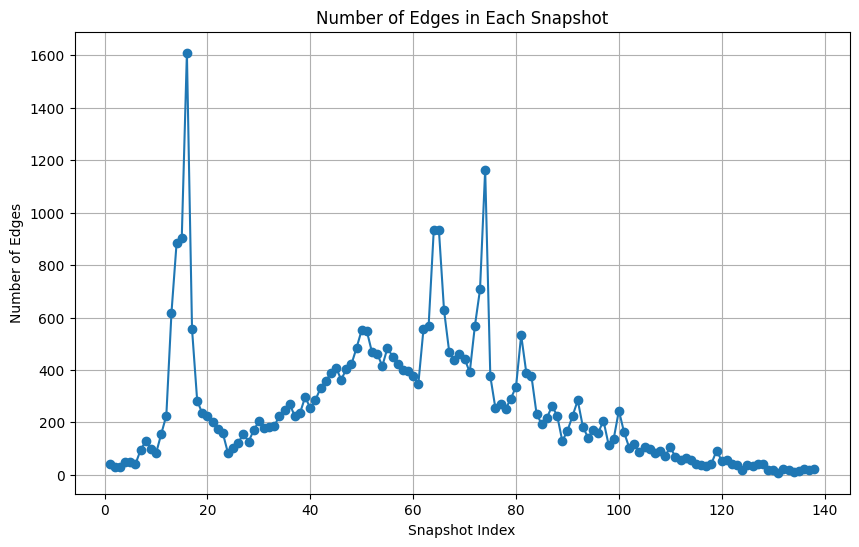

In [6]:
import matplotlib.pyplot as plt

snapshot_sizes = [s.number_of_edges() for s in snapshots]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(snapshot_sizes) + 1), snapshot_sizes, marker='o')
plt.title("Number of Edges in Each Snapshot")
plt.xlabel("Snapshot Index")
plt.ylabel("Number of Edges")
plt.grid(True)
plt.show()

In [7]:
edges_so_far = []

snapshots = []
for i in range(len(time_bins) - 1):
    start_ts = time_bins[i]
    end_ts = time_bins[i + 1]

    new_edges = [
        (u, v, d) for u, v, d in G_big.edges(data=True)
        if start_ts <= d["time"] < end_ts
    ]

    edges_so_far.extend(new_edges)

    H = nx.DiGraph()
    H.add_edges_from(edges_so_far)
    snapshots.append(H)

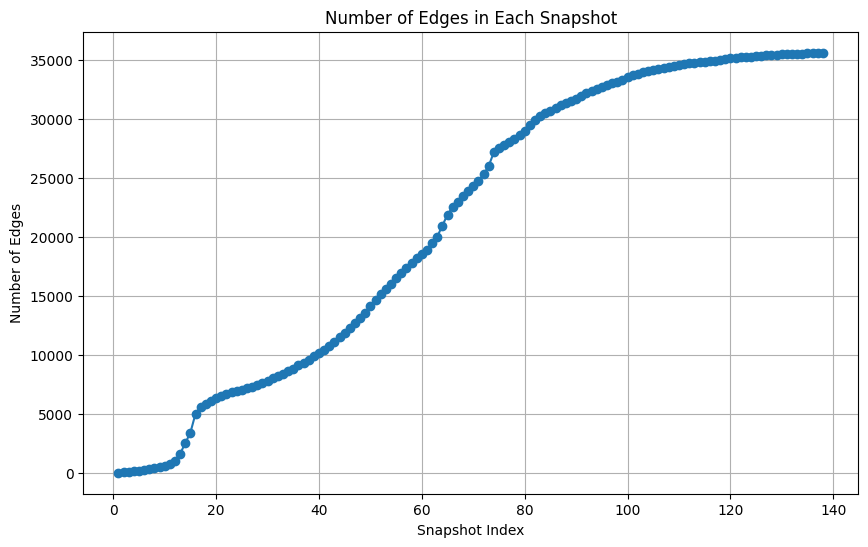

In [8]:
import matplotlib.pyplot as plt

snapshot_sizes = [s.number_of_edges() for s in snapshots]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(snapshot_sizes) + 1), snapshot_sizes, marker='o')
plt.title("Number of Edges in Each Snapshot")
plt.xlabel("Snapshot Index")
plt.ylabel("Number of Edges")
plt.grid(True)
plt.show()

In the cumulative temporal representation, each snapshot contains all interactions observed up to that time, allowing us to study the long-term structural evolution and consolidation of trust relationships in the network.

# 2. visualization

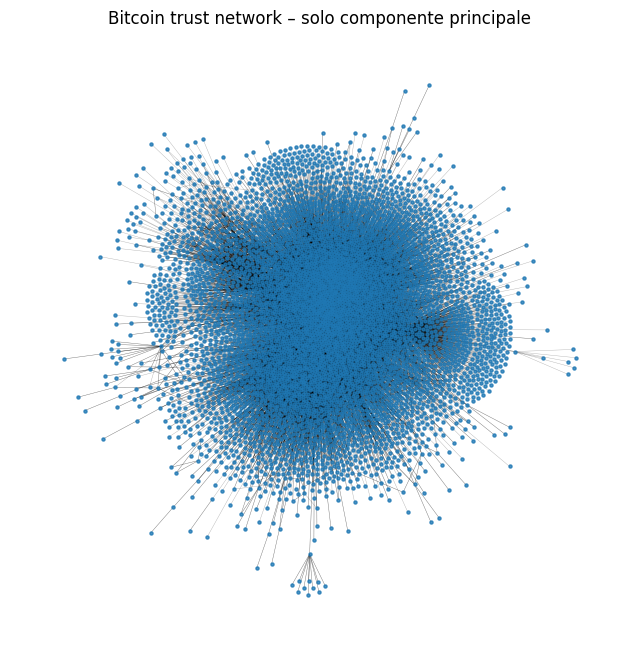

In [9]:
pos_big = {n: (d["x"], d["y"]) for n, d in G_big.nodes(data=True)}

plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(G_big, pos_big, node_size=5, alpha=0.8)
nx.draw_networkx_edges(G_big, pos_big, width=0.3, alpha=0.3, arrows=False)
plt.axis("off")
plt.title("Bitcoin trust network – solo componente principale")
plt.show()

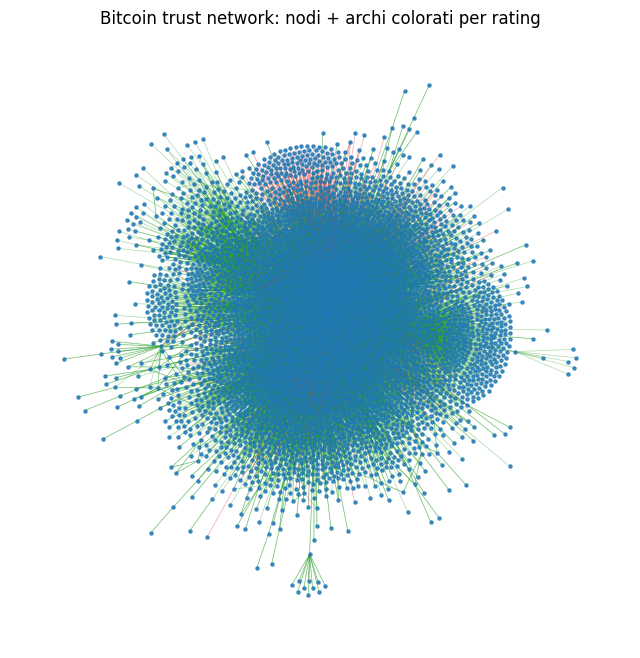

In [10]:
G = G_big

# dizionario: nodo -> (x, y)
pos = {n: (d["x"], d["y"]) for n, d in G.nodes(data=True)}

edge_colors = []
for u, v, data in G.edges(data=True):
    r = data.get("rating", 0)
    if r > 0:
        edge_colors.append("tab:green")   # fiducia positiva
    elif r < 0:
        edge_colors.append("tab:red")    # fiducia negativa
    else:
        edge_colors.append("lightgray")  # neutro
        
plt.figure(figsize=(8, 8))

# nodi piccoli e semitrasparenti
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=5,
    alpha=0.8
)

# archi colorati in base al rating
nx.draw_networkx_edges(
    G,
    pos,
    edge_color=edge_colors,
    alpha=0.4,
    width=0.5,
    arrows=False   # niente frecce per alleggerire
)

plt.axis("off")
plt.title("Bitcoin trust network: nodi + archi colorati per rating")
plt.show()


In [11]:
G_to_export = G  # oppure G_big se preferisci

nx.write_gexf(G_to_export, "bitcoin_trust.gexf")
print("File GEXF salvato come 'bitcoin_trust.gexf'")

File GEXF salvato come 'bitcoin_trust.gexf'


# 2. DEGREE

In [12]:
# Usa la tua giant component
G_emp = G_big
U_emp = G_emp.to_undirected()

n = U_emp.number_of_nodes()
m = U_emp.number_of_edges()

def metrics_und(U: nx.Graph) -> dict:
    return {
        "n": U.number_of_nodes(),
        "m": U.number_of_edges(),
        "density": nx.density(U),
        "transitivity": nx.transitivity(U),
        "assortativity_deg": nx.degree_assortativity_coefficient(U),
        "n_components": nx.number_connected_components(U),
        "giant_cc_frac": len(max(nx.connected_components(U), key=len)) / U.number_of_nodes() if U.number_of_nodes() else np.nan,
    }

# Singola realizzazione ER
U_er = nx.gnm_random_graph(n=n, m=m, seed=42)

emp = metrics_und(U_emp)
er  = metrics_und(U_er)

baseline_df = pd.DataFrame([emp, er], index=["EMPIRICAL", "ER_gnm"])
display(baseline_df)

,n,m,density,transitivity,assortativity_deg,n_components,giant_cc_frac
EMPIRICAL,5875,21489,0.001245,0.059238,-0.164887,1,1.000000
ER_gnm,5875,21489,0.001245,0.001333,-0.002491,8,0.998809


In [13]:
def er_ensemble(n, m, R=20, seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    for i in range(R):
        U = nx.gnm_random_graph(n=n, m=m, seed=int(rng.integers(0, 1e9)))
        rows.append(metrics_und(U))
    df = pd.DataFrame(rows)
    return df.mean(numeric_only=True), df.std(numeric_only=True)

er_mean, er_std = er_ensemble(n, m, R=20, seed=42)

comp = pd.DataFrame({
    "EMP": pd.Series(emp),
    "ER_mean": er_mean,
    "ER_std": er_std
})
display(comp)

,EMP,ER_mean,ER_std
n,5875.000000,5875.000000,0.000000
m,21489.000000,21489.000000,0.000000
density,0.001245,0.001245,0.000000
transitivity,0.059238,0.001188,0.000174
assortativity_deg,-0.164887,-0.004810,0.005436
n_components,1.000000,4.750000,2.268201
giant_cc_frac,1.000000,0.999362,0.000386


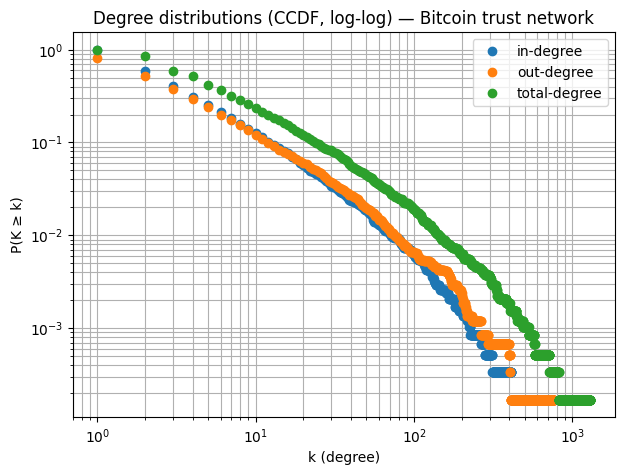

,metric,in-degree,out-degree,total-degree
0,mean,6.057362,6.057362,12.114723
1,median,2.000000,2.000000,4.000000
2,max,535.000000,763.000000,1298.000000
3,p95,21.000000,24.000000,44.000000
4,p99,71.000000,74.260000,142.260000


In [14]:

G = G_big  

# --- 1) Compute degrees ---
in_deg = np.array([d for _, d in G.in_degree()], dtype=int)
out_deg = np.array([d for _, d in G.out_degree()], dtype=int)
tot_deg = in_deg + out_deg

# --- 2) Helper: CCDF ---
def ccdf(deg_array):
    """
    Returns (k_values, P(K >= k)) for degree array.
    CCDF is less noisy and works well for heavy-tailed distributions.
    """
    deg_array = np.asarray(deg_array)
    deg_array = deg_array[deg_array >= 0]
    max_k = deg_array.max() if len(deg_array) else 0
    counts = np.bincount(deg_array, minlength=max_k + 1)
    pdf = counts / counts.sum() if counts.sum() > 0 else counts
    ccdf_vals = np.cumsum(pdf[::-1])[::-1]  # P(K >= k)
    k_vals = np.arange(len(ccdf_vals))
    return k_vals, ccdf_vals

# --- 3) Plot CCDF in log-log (deliverable) ---
plt.figure(figsize=(7,5))
for arr, label in [(in_deg, "in-degree"), (out_deg, "out-degree"), (tot_deg, "total-degree")]:
    k, y = ccdf(arr)
    mask = (k > 0) & (y > 0)   # avoid log(0)
    plt.loglog(k[mask], y[mask], marker='o', linestyle='None', label=label)

plt.title("Degree distributions (CCDF, log-log) — Bitcoin trust network")
plt.xlabel("k (degree)")
plt.ylabel("P(K ≥ k)")
plt.grid(True, which="both")
plt.legend()
plt.show()

# --- 4) Quick numeric summary (useful for the report) ---
summary = pd.DataFrame({
    "metric": ["mean", "median", "max", "p95", "p99"],
    "in-degree": [np.mean(in_deg), np.median(in_deg), np.max(in_deg), np.percentile(in_deg,95), np.percentile(in_deg,99)],
    "out-degree": [np.mean(out_deg), np.median(out_deg), np.max(out_deg), np.percentile(out_deg,95), np.percentile(out_deg,99)],
    "total-degree": [np.mean(tot_deg), np.median(tot_deg), np.max(tot_deg), np.percentile(tot_deg,95), np.percentile(tot_deg,99)],
})
display(summary)

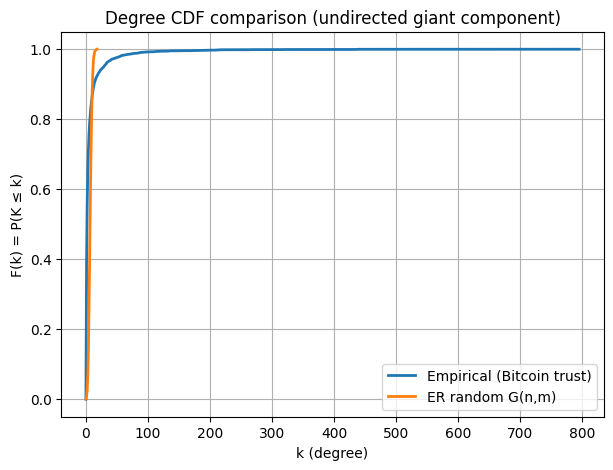

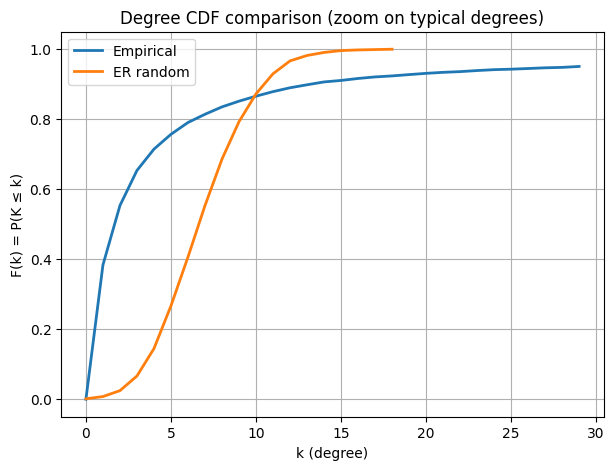

In [15]:
# --- 1) Choose empirical graph (use giant component) ---
G = G_big
U_emp = G.to_undirected()

n = U_emp.number_of_nodes()
m = U_emp.number_of_edges()

# --- 2) Build ER random model with same n, m ---
U_er = nx.gnm_random_graph(n=n, m=m, seed=42)

# --- 3) Extract degree arrays ---
deg_emp = np.array([d for _, d in U_emp.degree()], dtype=int)
deg_er  = np.array([d for _, d in U_er.degree()], dtype=int)

# --- 4) Helper: CDF ---
def cdf(deg_array):
    deg_array = np.asarray(deg_array, dtype=int)
    max_k = deg_array.max() if len(deg_array) else 0
    counts = np.bincount(deg_array, minlength=max_k + 1)
    pdf = counts / counts.sum() if counts.sum() > 0 else counts
    cdf_vals = np.cumsum(pdf)  # F(k) = P(K <= k)
    k_vals = np.arange(len(cdf_vals))
    return k_vals, cdf_vals

k_emp, F_emp = cdf(deg_emp)
k_er,  F_er  = cdf(deg_er)

# --- 5) Plot: CDF (linear scale) ---
plt.figure(figsize=(7,5))
plt.plot(k_emp, F_emp, label="Empirical (Bitcoin trust)", linewidth=2)
plt.plot(k_er,  F_er,  label="ER random G(n,m)", linewidth=2)
plt.title("Degree CDF comparison (undirected giant component)")
plt.xlabel("k (degree)")
plt.ylabel("F(k) = P(K ≤ k)")
plt.grid(True)
plt.legend()
plt.show()

# --- 6) Optional: zoom on low degrees (often where differences are visible) ---
plt.figure(figsize=(7,5))
k_max_zoom = int(np.percentile(deg_emp, 95))  # zoom up to 95th percentile
plt.plot(k_emp[k_emp <= k_max_zoom], F_emp[k_emp <= k_max_zoom], label="Empirical", linewidth=2)
plt.plot(k_er[k_er <= k_max_zoom],  F_er[k_er <= k_max_zoom],  label="ER random", linewidth=2)
plt.title("Degree CDF comparison (zoom on typical degrees)")
plt.xlabel("k (degree)")
plt.ylabel("F(k) = P(K ≤ k)")
plt.grid(True)
plt.legend()
plt.show()

# 3. NETWORK DENSITY


Network density measures how close the trust network is to being fully connected. In our Bitcoin trust network, density helps us understand whether trust ratings create a sparse system (typical in large social platforms) or a relatively dense one. This matters because many properties (community detection, diffusion, clustering, centrality, and even the comparison with random models) depend strongly on how sparse the graph is.
In practice: if density is extremely low, the network is selective (users rate only a tiny fraction of possible others), and hubs/heterogeneity become much more important for connectivity.

,graph,n,m,density_directed
0,Full graph,5875,35587,0.001031
1,Giant WCC (G_big),5875,35587,0.001031


,snapshot,n,m,density
0,1,22,41,0.088745
1,2,30,72,0.082759
2,3,39,101,0.068151
3,4,56,148,0.048052
4,5,71,196,0.039437


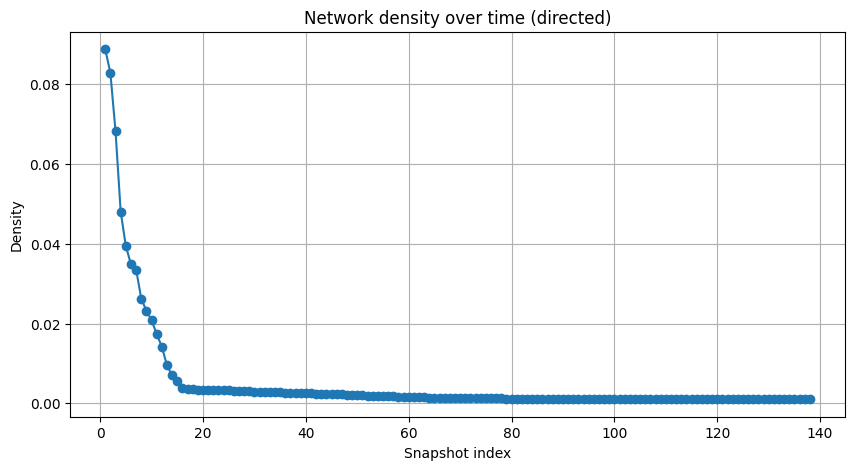

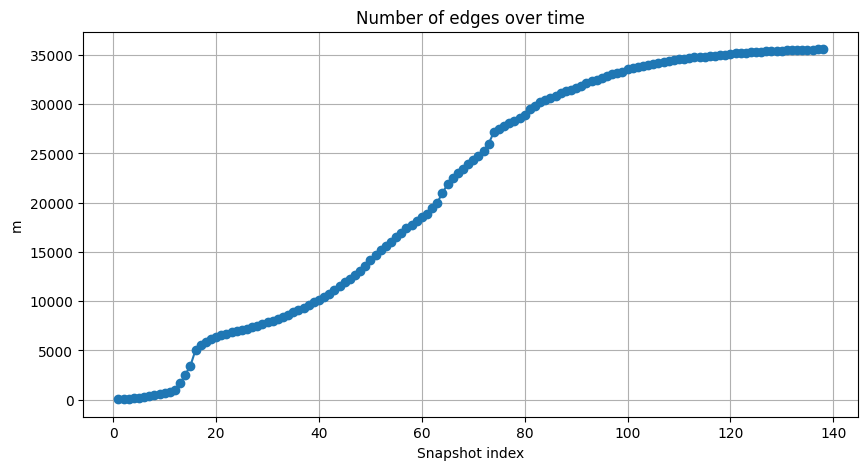

In [16]:
# --- 1) Density on full graph and giant component (directed) ---
G_full = G          
G_gc   = G_big

def directed_density(D: nx.DiGraph) -> float:
    # For directed graphs: density = m / (n*(n-1)) (no self-loops)
    n = D.number_of_nodes()
    m = D.number_of_edges()
    return m / (n * (n - 1)) if n > 1 else np.nan

stats = []
for name, D in [("Full graph", G_full), ("Giant WCC (G_big)", G_gc)]:
    n = D.number_of_nodes()
    m = D.number_of_edges()
    stats.append({
        "graph": name,
        "n": n,
        "m": m,
        "density_directed": directed_density(D)
    })

density_df = pd.DataFrame(stats)
display(density_df)

# --- 2) Density over time (snapshots) ---
# snapshots = your list of graphs (per-bin or cumulative), already created
dens_t = [directed_density(S) for S in snapshots]
m_t    = [S.number_of_edges() for S in snapshots]
n_t    = [S.number_of_nodes() for S in snapshots]

time_df = pd.DataFrame({
    "snapshot": np.arange(1, len(snapshots) + 1),
    "n": n_t,
    "m": m_t,
    "density": dens_t
})
display(time_df.head())

plt.figure(figsize=(10,5))
plt.plot(time_df["snapshot"], time_df["density"], marker="o")
plt.title("Network density over time (directed)")
plt.xlabel("Snapshot index")
plt.ylabel("Density")
plt.grid(True)
plt.show()

# --- 3) (Optional but useful) Compare density vs edges growth ---
plt.figure(figsize=(10,5))
plt.plot(time_df["snapshot"], time_df["m"], marker="o")
plt.title("Number of edges over time")
plt.xlabel("Snapshot index")
plt.ylabel("m")
plt.grid(True)
plt.show()

# 4. RECIPROCITY    

How sparse is the Bitcoin trust network?
In our case, density tells us the fraction of all possible trust links that actually exist. Because this network is large, we expect it to be very sparse: users rate only a tiny subset of other users. This matters because sparsity strongly affects later analyses (e.g., clustering, community detection, and comparisons with random models).

In [17]:
import pandas as pd
import networkx as nx

rows = []
for name, H in [("Full graph", G), ("Giant component (G_big)", G_big)]:
    rows.append({
        "Graph": name,
        "n": H.number_of_nodes(),
        "m": H.number_of_edges(),
        "density": nx.density(H)
    })

df_density = pd.DataFrame(rows)
display(df_density)

,Graph,n,m,density
0,Full graph,5875,35587,0.001031
1,Giant component (G_big),5875,35587,0.001031


# 5. CONECTED COMPONENT

Is the Bitcoin trust network connected, or does it split into isolated groups?
Because edges are directed (user rates another user), we look at:
	
•	Weakly connected components (WCCs): ignores direction → tells us whether users are connected at least indirectly.
	
•	Strongly connected components (SCCs): respects direction → tells us whether there are groups where everyone can reach everyone else via directed paths (important for feedback loops and mutual interaction).

In [18]:

n = G.number_of_nodes()

# 1) Weakly connected components (ignore direction)
wcc = list(nx.weakly_connected_components(G))
wcc_sizes = sorted([len(c) for c in wcc], reverse=True)

# 2) Strongly connected components (respect direction)
scc = list(nx.strongly_connected_components(G))
scc_sizes = sorted([len(c) for c in scc], reverse=True)

print(f"Number of nodes: {n}")

print(f"\nNumber of weakly connected components (WCC): {len(wcc)}")
print(f"Sizes of the 5 largest WCCs: {wcc_sizes[:5]}")
print(f"Giant WCC fraction: {wcc_sizes[0]/n:.4f}")

print(f"\nNumber of strongly connected components (SCC): {len(scc)}")
print(f"Sizes of the 5 largest SCCs: {scc_sizes[:5]}")
print(f"Largest SCC fraction: {scc_sizes[0]/n:.4f}")

Number of nodes: 5875

Number of weakly connected components (WCC): 1
Sizes of the 5 largest WCCs: [5875]
Giant WCC fraction: 1.0000

Number of strongly connected components (SCC): 1140
Sizes of the 5 largest SCCs: [4709, 6, 3, 3, 3]
Largest SCC fraction: 0.8015


# 6. TRANSITIVITY

Does the Bitcoin trust network show evidence of triadic closure (tight local groups)?
Clustering captures whether “a friend of my friend is also my friend.” In our trust network, higher clustering suggests that trust ties tend to form locally dense groups, which can indicate community-like behavior and repeated interactions among subsets of users.

In [19]:

G_und = G.to_undirected()

global_clustering = nx.transitivity(G_und)
avg_local_clustering = nx.average_clustering(G_und)

print(f"Global clustering coefficient (transitivity): {global_clustering:.4f}")
print(f"Average local clustering coefficient: {avg_local_clustering:.4f}")

Global clustering coefficient (transitivity): 0.0592
Average local clustering coefficient: 0.1777


In [20]:

G_und = G.to_undirected()

# local clustering per node
clust = nx.clustering(G_und)
vals = np.array(list(clust.values()), dtype=float)

print("Local clustering coefficient distribution (summary):")
print(f"n nodes: {len(vals)}")
print(f"min: {vals.min():.4f}")
print(f"p25: {np.percentile(vals,25):.4f}")
print(f"median: {np.median(vals):.4f}")
print(f"mean: {vals.mean():.4f}")
print(f"p75: {np.percentile(vals,75):.4f}")
print(f"p90: {np.percentile(vals,90):.4f}")
print(f"p95: {np.percentile(vals,95):.4f}")
print(f"max: {vals.max():.4f}")

print("\nMass at extremes:")
print(f"fraction with C=0:  {(vals==0).mean():.4f}")
print(f"fraction with C=1:  {(vals==1).mean():.4f}")

Local clustering coefficient distribution (summary):
n nodes: 5875
min: 0.0000
p25: 0.0000
median: 0.0000
mean: 0.1777
p75: 0.2439
p90: 0.6667
p95: 1.0000
max: 1.0000

Mass at extremes:
fraction with C=0:  0.5551
fraction with C=1:  0.0766


The distribution shows many nodes with low clustering and a non-negligible fraction with moderate-to-high clustering, suggesting that triadic closure exists but is not uniform across users—some users belong to tightly knit trust circles.

# 7. BRIDGES

Which connections are structurally critical for holding the Bitcoin trust network together?
In our trust network, “bridges” identify vulnerable or bottleneck links: edges whose removal would disconnect parts of the network (bridges), or would at least make their endpoints much farther apart (local bridges). This helps us detect boundary-spanning connections that connect otherwise separate regions of the network.


In [21]:

# 7.1 undirected graph
G_und = G.to_undirected()

# 7.2 Compute bridges
bridges = list(nx.bridges(G_und))
print(f"Number of bridges in the undirected graph: {len(bridges)} ({len(bridges)/G_und.number_of_edges():.2%} of edges)")
print("Sample bridges:", bridges[:10])

# 7.3 Compute local bridges (distance between endpoints increases if edge removed)
local_bridges = list(nx.local_bridges(G_und, with_span=False))
print(f"Number of local bridges in the undirected graph: {len(local_bridges)} ({len(local_bridges)/G_und.number_of_edges():.2%} of edges)")
print("Sample local bridges:", local_bridges[:10])

Number of bridges in the undirected graph: 2287 (10.64% of edges)
Sample bridges: [(1, 712), (3, 45), (3, 47), (3, 103), (3, 202), (3, 267), (3, 375), (3, 448), (3, 456), (3, 644)]
Number of local bridges in the undirected graph: 6402 (29.79% of edges)
Sample local bridges: [(0, 213), (0, 223), (0, 1575), (1, 340), (1, 586), (1, 608), (1, 602), (1, 712), (1, 104), (3, 45)]


# 8. ASSORTATIVITY

In [22]:

G_und = G.to_undirected()

r = nx.degree_assortativity_coefficient(G_und)
print(f"Degree assortativity (undirected): {r:.4f}")

Degree assortativity (undirected): -0.1649


# 9. CENTRALLITY MEASURES

Who are the structurally most important individuals in the Bitcoin trust network?
Different centrality measures capture different “roles” in the network:

•	Degree centrality highlights highly active/visible users (many connections).

•	Betweenness centrality identifies brokers that sit on many shortest paths (potential gatekeepers).

•	Closeness centrality captures nodes that are, on average, at short distance from others (well-positioned globally).

•	PageRank identifies nodes that are important because they are connected to other important nodes (influence via network flow).


In [23]:

G_und = G.to_undirected()

# 9.1 Degree centrality (undirected)
deg_cent = nx.degree_centrality(G_und)

# 9.2 Betweenness centrality (undirected) - exact (can be expensive)
bet_cent = nx.betweenness_centrality(G_und, normalized=True)

# 9.3 Closeness centrality (undirected)
clo_cent = nx.closeness_centrality(G_und)

# 9.4 PageRank (directed)
pr = nx.pagerank(G, alpha=0.85)

centrality_df = pd.DataFrame({
    "node": list(G.nodes()),
    "user_id": [G.nodes[n].get("user_id", None) for n in G.nodes()],
    "degree_centrality": [deg_cent.get(n, 0.0) for n in G.nodes()],
    "betweenness_centrality": [bet_cent.get(n, 0.0) for n in G.nodes()],
    "closeness_centrality": [clo_cent.get(n, 0.0) for n in G.nodes()],
    "pagerank": [pr.get(n, 0.0) for n in G.nodes()],
})

display(centrality_df.head())

def show_top(df, col, k=10):
    print(f"\nTop {k} nodes by {col}:")
    display(df.sort_values(col, ascending=False).head(k)[["node", "user_id", col]])

show_top(centrality_df, "degree_centrality")
show_top(centrality_df, "betweenness_centrality")
show_top(centrality_df, "closeness_centrality")
show_top(centrality_df, "pagerank")

,node,user_id,degree_centrality,betweenness_centrality,closeness_centrality,pagerank
0,0,6,0.009363,0.004401,0.388929,0.000775
1,1,2,0.009023,0.002365,0.340858,0.000978
2,2,5,0.000511,0.000000,0.311982,0.000093
3,3,1,0.044944,0.052918,0.433474,0.005034
4,4,15,0.002894,0.000697,0.322004,0.000323



Top 10 nodes by degree_centrality:


,node,user_id,degree_centrality
23,23,35,0.135342
1785,1785,1810,0.074736
2571,2571,2642,0.074566
2071,2071,2125,0.074225
1980,1980,2028,0.055499
945,945,905,0.054477
4067,4071,4172,0.049881
3,3,1,0.044944
10,10,7,0.040688
3032,3032,3129,0.036942



Top 10 nodes by betweenness_centrality:


,node,user_id,betweenness_centrality
23,23,35,0.193538
2071,2071,2125,0.077898
2571,2571,2642,0.064856
1785,1785,1810,0.061748
3,3,1,0.052918
945,945,905,0.052692
3032,3032,3129,0.052070
4067,4071,4172,0.049763
1980,1980,2028,0.044561
10,10,7,0.039361



Top 10 nodes by closeness_centrality:


,node,user_id,closeness_centrality
945,945,905,0.436469
3,3,1,0.433474
23,23,35,0.427916
2569,2569,2388,0.419392
1785,1785,1810,0.411373
2571,2571,2642,0.410884
7,7,13,0.410511
2238,2238,2296,0.408058
1980,1980,2028,0.407718
2071,2071,2125,0.407379



Top 10 nodes by pagerank:


,node,user_id,pagerank
23,23,35,0.015122
2571,2571,2642,0.010827
1785,1785,1810,0.006983
1980,1980,2028,0.006783
10,10,7,0.005918
945,945,905,0.005378
1899,1899,1953,0.005165
3,3,1,0.005034
4067,4071,4172,0.004790
4085,4089,4197,0.004677


Centrality measures consistently highlight a small set of nodes as structurally dominant. In particular, node 23 ranks first in degree, betweenness, and PageRank, indicating it acts both as a hub and as a key broker on shortest paths

# 10. COMUNITY DETECTION AND COMPARISON EITH GROUNF TRUTH

Do interaction-driven communities in the Bitcoin trust network align with an external grouping label (ground truth)?
We detect communities from the network structure (who interacts with whom) and compare them to the available node labels. A higher agreement suggests that network interactions follow that external structure; lower agreement suggests more cross-group mixing or informal structure.


In [24]:

# 10.0 Undirected graph
G_und = G.to_undirected()

# 10.1 Run community detection (Louvain)
if HAVE_NX_LOUVAIN:
    print("Using NetworkX's louvain_communities...")
    louvain_comms = louvain_communities(G_und, seed=42)
elif HAVE_COMMUNITY_LOUVAIN:
    print("Using python-louvain (community_louvain)...")
    partition = community_louvain.best_partition(G_und, random_state=42)
    # Convert partition dict {node: community_id} to list of sets
    comm_dict = {}
    for node, cid in partition.items():
        comm_dict.setdefault(cid, set()).add(node)
    louvain_comms = list(comm_dict.values())
else:
    print("No Louvain implementation found. Please install 'python-louvain' or upgrade NetworkX.")
    louvain_comms = []

print(f"Detected {len(louvain_comms)} communities.")

# 10.1b Compute community sizes + print stats (come nelle immagini)
community_sizes = sorted([len(c) for c in louvain_comms], reverse=True)
print(f"Number of communities: {len(community_sizes)}")
if len(community_sizes) > 0:
    print(f"Smallest community: {min(community_sizes)} nodes")
    print(f"Largest community: {max(community_sizes)} nodes")

# 10.2 Extract department labels (ground truth)
departments = nx.get_node_attributes(G, "department")
dept_sizes = pd.Series(departments).value_counts().sort_values(ascending=False)


Using NetworkX's louvain_communities...
Detected 14 communities.
Number of communities: 14
Smallest community: 3 nodes
Largest community: 1031 nodes


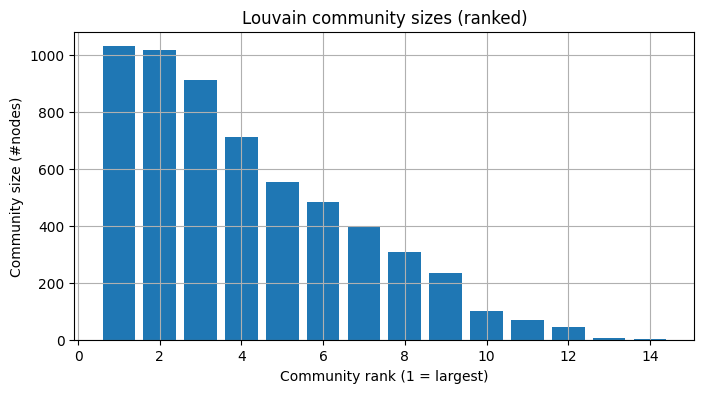

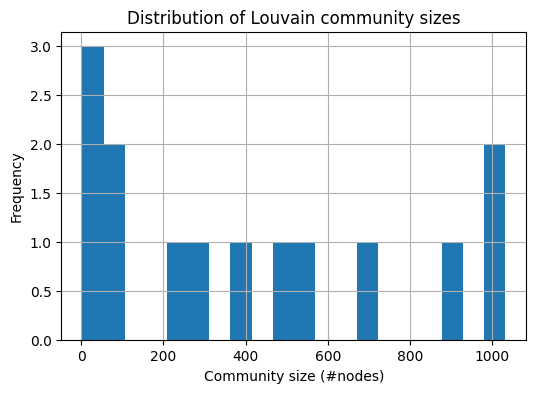

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# community_sizes should already exist from your Louvain step
# community_sizes = sorted([len(c) for c in louvain_comms], reverse=True)

# 1) Ranked bar plot (most informative)
plt.figure(figsize=(8,4))
plt.bar(range(1, len(community_sizes)+1), community_sizes)
plt.xlabel("Community rank (1 = largest)")
plt.ylabel("Community size (#nodes)")
plt.title("Louvain community sizes (ranked)")
plt.grid(True, axis="y")
plt.show()

# 2) Optional: histogram (can be less informative if very skewed)
plt.figure(figsize=(6,4))
plt.hist(community_sizes, bins=20)
plt.xlabel("Community size (#nodes)")
plt.ylabel("Frequency")
plt.title("Distribution of Louvain community sizes")
plt.grid(True, axis="y")
plt.show()




# 11. ML PART

In [26]:
import numpy as np
import pandas as pd
import networkx as nx

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split


# 11) Choose graph

G = G_big


# 1) Temporal split (edges)

edges_with_time = [(u, v, d["time"]) for u, v, d in G.edges(data=True) if "time" in d]
edges_with_time.sort(key=lambda x: x[2])

cut = int(0.8 * len(edges_with_time))
train_edges = [(u, v) for u, v, _ in edges_with_time[:cut]]
test_edges_pos = [(u, v) for u, v, _ in edges_with_time[cut:]]

# Build train graph (undirected for topology-based predictors)
G_train = nx.Graph()
G_train.add_nodes_from(G.nodes())
G_train.add_edges_from(train_edges)

# Positive test edges set for fast lookup
test_pos_set = set((min(u,v), max(u,v)) for u,v in test_edges_pos)

# 11.1) Negative sampling for test
rng = np.random.default_rng(42)
nodes = list(G_train.nodes())
existing_train = set((min(u,v), max(u,v)) for u,v in G_train.edges())

def sample_non_edges(k):
    neg = set()
    while len(neg) < k:
        u = rng.choice(nodes)
        v = rng.choice(nodes)
        if u == v:
            continue
        a, b = (u, v) if u < v else (v, u)
        if (a,b) in existing_train:
            continue
        if (a,b) in test_pos_set:
            continue
        neg.add((a,b))
    return list(neg)

test_edges_neg = sample_non_edges(len(test_edges_pos))


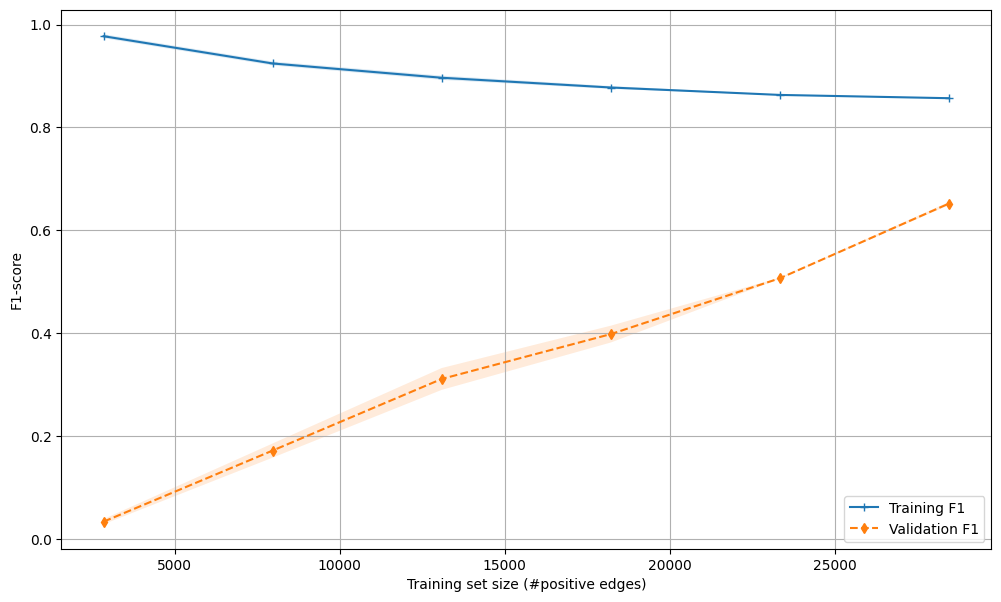

In [27]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

train_edges_all = train_edges  # alias

def canon(u, v):
    return (u, v) if u < v else (v, u)

# FAST features: only cheap ones
def fast_features_for_pairs(Gx, pairs):
    cn = []
    deg_u = []
    deg_v = []
    pref = []

    for u, v in pairs:
        # common neighbors (cheap-ish)
        cn.append(len(list(nx.common_neighbors(Gx, u, v))) if Gx.has_node(u) and Gx.has_node(v) else 0)
        du = Gx.degree(u)
        dv = Gx.degree(v)
        deg_u.append(du)
        deg_v.append(dv)
        pref.append(du * dv)

    return pd.DataFrame({
        "common_neighbors": cn,
        "pref_attach": pref,
        "deg_u": deg_u,
        "deg_v": deg_v
    })

def sample_non_edges_from_graph(Gx, k, forbidden=set()):
    existing = set(canon(u, v) for u, v in Gx.edges())
    neg = set()
    while len(neg) < k:
        u = rng.choice(nodes)
        v = rng.choice(nodes)
        if u == v:
            continue
        a, b = canon(u, v)
        if (a, b) in existing:
            continue
        if (a, b) in forbidden:
            continue
        neg.add((a, b))
    return list(neg)

# Fewer points + fewer repeats (faster)
min_size = max(500, int(0.1 * len(train_edges_all)))
max_size = len(train_edges_all)
train_sizes = np.linspace(min_size, max_size, 6, dtype=int)

n_repeats = 3
threshold = 0.5

train_scores = np.zeros((len(train_sizes), n_repeats))
val_scores   = np.zeros((len(train_sizes), n_repeats))

for i, k in enumerate(train_sizes):
    train_edges_k = train_edges_all[:k]

    G_train_k = nx.Graph()
    G_train_k.add_nodes_from(G_train.nodes())
    G_train_k.add_edges_from(train_edges_k)

    train_pos = [canon(u, v) for u, v in train_edges_k]
    val_pos = [canon(u, v) for u, v in test_edges_pos]

    for r in range(n_repeats):
        train_neg = sample_non_edges_from_graph(G_train_k, len(train_pos))
        val_neg   = sample_non_edges_from_graph(G_train_k, len(val_pos), forbidden=test_pos_set)

        X_train = pd.concat(
            [fast_features_for_pairs(G_train_k, train_pos),
             fast_features_for_pairs(G_train_k, train_neg)],
            ignore_index=True
        )
        y_train = np.array([1]*len(train_pos) + [0]*len(train_neg))

        clf = LogisticRegression(max_iter=1000, class_weight="balanced")
        clf.fit(X_train, y_train)

        p_train = clf.predict_proba(X_train)[:, 1]
        yhat_train = (p_train >= threshold).astype(int)
        train_scores[i, r] = f1_score(y_train, yhat_train)

        X_val = pd.concat(
            [fast_features_for_pairs(G_train_k, val_pos),
             fast_features_for_pairs(G_train_k, val_neg)],
            ignore_index=True
        )
        y_val = np.array([1]*len(val_pos) + [0]*len(val_neg))

        p_val = clf.predict_proba(X_val)[:, 1]
        yhat_val = (p_val >= threshold).astype(int)
        val_scores[i, r] = f1_score(y_val, yhat_val)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(1, 1, 1)

ax.plot(train_sizes, train_mean, marker='+', markersize=6, label="Training F1")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)

ax.plot(train_sizes, val_mean, linestyle='--', marker='d', markersize=5, label="Validation F1")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)

ax.grid(True)
ax.set_xlabel("Training set size (#positive edges)")
ax.set_ylabel("F1-score")
ax.legend(loc="lower right")
plt.show()

The learning curve shows a clear data-driven improvement in generalization: the validation F1 steadily increases as more past edges are included in training (from very low values at small training sizes up to ~0.65 at the largest size). In parallel, training F1 slightly decreases and stabilizes, indicating reduced overfitting as the training set grows. The remaining gap between training and validation suggests that the task is still challenging and that additional signal (e.g., richer features or models) could further improve performance, but overall the model benefits substantially from having more historical network data.